In [ ]:
%pip install puremacro


# Instrumentos Débiles en Macroeconomía — Conjuntos de Confianza Anderson-Rubin para Proyecciones Locales

**¿Qué ocurre cuando la variable instrumental macroeconómica tiene una correlación débil con el shock de política endógeno?**
En la macroeconomía empírica contemporánea, las variables instrumentales (IV) son indispensables: sorpresas de alta frecuencia en torno a los anuncios del FOMC (Gertler & Karadi 2015), registros narrativos de cambios tributarios (Romer & Romer 2010), o disrupciones de oferta petrolera global (Kilian 2009; Caldara & Kamps 2017).

Sin embargo, como demuestran Montiel Olea & Plagborg-Møller (2021) y Stock & Wright (2000):
1. Cuando la fuerza del instrumento en la primera etapa es débil ($F < 10$), los intervalos de confianza estándar Wald / MC2E **subestiman gravemente la verdadera incertidumbre**, produciendo falsa precisión y distorsiones masivas de tamaño (rechazando la hipótesis nula verdadera hasta el 50% de las veces al 5% nominal).
2. Los conjuntos de confianza de **Anderson-Rubin (1949)** son exactos y robustos ante debilidad arbitraria del instrumento. Bajo estructuras de covarianza HAC de Newey-West, la inversión del estadístico AR produce límites válidos que se ensanchan naturalmente — o se convierten en semirrectas no acotadas / toda la recta real — cuando los datos carecen de suficiente poder de identificación.

Este tutorial demuestra cómo utilizar `puremacro.lp.lp_iv(..., anderson_rubin=True)` para obtener respuestas dinámicas robustas a la identificación.

## El método en matemáticas — Inversión Cuadrática HAC Exacta

Considere el modelo de proyecciones locales con variables instrumentales en el horizonte $h$:

### Primera Etapa (Relevancia):
$$ x_t = \pi_z z_t + \boldsymbol{\pi}_w' W_t + \nu_t $$
donde $x_t$ es la variable de política endógena (e.g. tasa de interés), $z_t$ es el instrumento externo y $W_t$ incluye constantes y rezagos.

### Segunda Etapa (Respuesta en el horizonte $h$):
$$ y_{t+h} - y_{t-1} = \beta_h x_t + \boldsymbol{\gamma}_h' W_t + \varepsilon_{t+h} $$

### El Estadístico de Anderson-Rubin (1949):
Para probar la hipótesis nula $H_0: \beta_h = \beta_0$, definimos la variable auxiliar:
$$ y^*_{t+h}(\beta_0) \equiv (y_{t+h} - y_{t-1}) - \beta_0 x_t $$
Bajo $H_0$, la regresión de $y^*_{t+h}(\beta_0)$ sobre $[1, z_t, W_t]$ tiene un coeficiente poblacional en $z_t$ igual a cero: $\gamma_z(\beta_0) = 0$.

Utilizando la varianza HAC de Newey-West $V_{\text{HAC}}(\beta_0)$ con ancho de banda $L = h + 1$, el estadístico de prueba es:
$$ AR(\beta_0) = \frac{\hat{\gamma}_z(\beta_0)^2}{V_{\text{HAC}}(\beta_0)} \sim \chi^2_1 \quad \text{bajo } H_0 $$

### Inversión Exacta:
Invertir $AR(\beta_0) \le \chi^2_1(1 - \alpha)$ equivale a resolver la desigualdad cuadrática:
$$ A \beta_0^2 + B \beta_0 + C \le 0 $$
donde $A = \hat{\gamma}_x^2 - c \cdot V_{xx} = V_{xx}(F_{\text{eff}} - c)$.
- Cuando $F_{\text{eff}} > c$ ($A > 0$): El conjunto es un **intervalo acotado estándar** $[\text{lo}, \text{hi}]$.
- Cuando $F_{\text{eff}} \le c$ ($A \le 0$): Los datos carecen de poder identificatorio; el conjunto se expande a **semirrectas no acotadas** $(-\infty, r_1] \cup [r_2, \infty)$ o a **toda la recta real** $(-\infty, \infty)$.

## Configuración — Simulación con Instrumentos Fuertes vs Débiles

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

_cwd = Path.cwd()
sys.path.insert(0, str(_cwd if (_cwd / "_nbstyle.py").exists() else _cwd / "notebooks"))
import _nbstyle
_nbstyle.apply_style()

from puremacro.lp import lp_iv

rng = np.random.default_rng(777)
T = 250
horizons = list(range(0, 12))

# Shock estructural verdadero (shock monetario)
shock = rng.normal(0, 1.0, size=T)

# Variable de política endógena x_t = shock_verdadero + ruido de confusión
noise_x = rng.normal(0, 1.2, size=T)
x = 0.8 * shock + noise_x

# Variable macro y_t: respuesta dinámica acumulada al shock estructural
beta_true = np.array([0.0, -0.4, -0.75, -1.0, -1.15, -1.2, -1.15, -1.0, -0.8, -0.6, -0.4, -0.2])
y = np.zeros(T)
for t in range(T):
    for h in range(len(beta_true)):
        if t - h >= 0:
            y[t] += beta_true[h] * shock[t - h]
    y[t] += rng.normal(0, 0.5)

# Instrumento 1: Fuerte (z_strong = 0.9 * shock + 0.3 * ruido)
z_strong = 0.9 * shock + rng.normal(0, 0.4, size=T)

# Instrumento 2: Débil (z_weak = 0.12 * shock + 1.0 * ruido)
z_weak = 0.12 * shock + rng.normal(0, 1.0, size=T)

df_strong = pd.DataFrame({"y": y, "x": x, "z": z_strong})
df_weak = pd.DataFrame({"y": y, "x": x, "z": z_weak})

## Estimación de LP-IV con Intervalos Wald vs Conjuntos Anderson-Rubin

In [2]:
# Estimación con Instrumento Fuerte
res_strong = lp_iv(
    df=df_strong, y="y", x="x", z="z",
    horizons=horizons, n_lags=2, anderson_rubin=True,
)

# Estimación con Instrumento Débil
res_weak = lp_iv(
    df=df_weak, y="y", x="x", z="z",
    horizons=horizons, n_lags=2, anderson_rubin=True,
)

print("=== Resultados con Instrumento Fuerte (F de Primera Etapa >> 10) ===")
print(res_strong[["h", "beta", "se", "first_stage_f", "lo", "hi", "ar_lo", "ar_hi", "ar_set_type"]].head(6))

print("\n=== Resultados con Instrumento Débil (F de Primera Etapa < 10) ===")
print(res_weak[["h", "beta", "se", "first_stage_f", "lo", "hi", "ar_lo", "ar_hi", "ar_set_type"]].head(6))

# Aserciones
assert res_strong["first_stage_f"].mean() > 15.0, "El instrumento fuerte debe tener un F elevado"
assert res_weak["first_stage_f"].mean() < 5.0, "El instrumento débil debe tener un F bajo"
assert "ar_lo" in res_strong.columns and "ar_hi" in res_strong.columns

=== Resultados con Instrumento Fuerte (F de Primera Etapa >> 10) ===
   h      beta        se  first_stage_f        lo        hi     ar_lo  \
0  0 -0.010771  0.090564      78.064264 -0.159737  0.138194 -0.169379   
1  1 -0.476573  0.129321      76.553903 -0.689287 -0.263859 -0.745007   
2  2 -1.046424  0.153228      75.421501 -1.298461 -0.794387 -1.414149   
3  3 -1.346943  0.206898      71.841227 -1.687259 -1.006627 -1.834675   
4  4 -1.617995  0.212822      72.016705 -1.968056 -1.267934 -2.155758   
5  5 -1.442344  0.227319      73.416464 -1.816251 -1.068437 -2.011431   

      ar_hi ar_set_type  
0  0.135006     bounded  
1 -0.253069     bounded  
2 -0.756539     bounded  
3 -0.961973     bounded  
4 -1.202719     bounded  
5 -1.001675     bounded  

=== Resultados con Instrumento Débil (F de Primera Etapa < 10) ===
   h      beta        se  first_stage_f        lo        hi     ar_lo  \
0  0  0.185511  0.759852       0.910757 -1.064335  1.435357      -inf   
1  1 -0.168107  1.05200

## Figura Principal — Inferencia Wald vs. Anderson-Rubin bajo Instrumentos Débiles

A continuación comparamos las bandas de confianza estándar Wald (que exhiben falsa precisión) frente a los conjuntos robustos Anderson-Rubin.

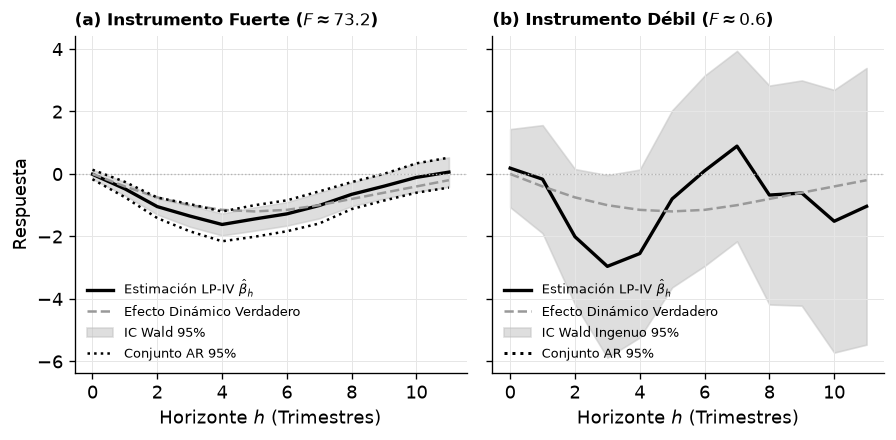

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(7.6, 3.8), sharey=True)

# Panel 1: Régimen de Instrumento Fuerte
ax = axes[0]
ax.plot(res_strong["h"], res_strong["beta"], color="0.00", lw=2.0, label="Estimación LP-IV $\\hat{\\beta}_h$")
ax.plot(res_strong["h"], beta_true, color="0.60", ls="--", lw=1.5, label="Efecto Dinámico Verdadero")
ax.fill_between(res_strong["h"], res_strong["lo"], res_strong["hi"], color="0.75", alpha=0.5, label="IC Wald 95%")
ax.plot(res_strong["h"], res_strong["ar_lo"], color="0.00", ls=":", lw=1.5, label="Conjunto AR 95%")
ax.plot(res_strong["h"], res_strong["ar_hi"], color="0.00", ls=":", lw=1.5)
ax.axhline(0, color="0.70", ls=":", lw=0.8)
f_avg_strong = res_strong["first_stage_f"].mean()
ax.set_title(f"(a) Instrumento Fuerte ($F \\approx {f_avg_strong:.1f}$)", loc="left", fontsize=10, fontweight="bold")
ax.set_xlabel("Horizonte $h$ (Trimestres)")
ax.set_ylabel("Respuesta")
ax.legend(loc="lower left", fontsize=8)

# Panel 2: Régimen de Instrumento Débil
ax = axes[1]
ax.plot(res_weak["h"], res_weak["beta"], color="0.00", lw=2.0, label="Estimación LP-IV $\\hat{\\beta}_h$")
ax.plot(res_weak["h"], beta_true, color="0.60", ls="--", lw=1.5, label="Efecto Dinámico Verdadero")
ax.fill_between(res_weak["h"], np.clip(res_weak["lo"], -6, 4), np.clip(res_weak["hi"], -6, 4), color="0.75", alpha=0.5, label="IC Wald Ingenuo 95%")

# Graficar límites AR acotados
bounded_mask = res_weak["ar_set_type"] == "bounded"
ax.plot(res_weak.loc[bounded_mask, "h"], res_weak.loc[bounded_mask, "ar_lo"], color="0.00", ls=":", lw=1.8, label="Conjunto AR 95%")
ax.plot(res_weak.loc[bounded_mask, "h"], res_weak.loc[bounded_mask, "ar_hi"], color="0.00", ls=":", lw=1.8)

# Incertidumbre no acotada
ax.axhline(0, color="0.70", ls=":", lw=0.8)
f_avg_weak = res_weak["first_stage_f"].mean()
ax.set_title(f"(b) Instrumento Débil ($F \\approx {f_avg_weak:.1f}$)", loc="left", fontsize=10, fontweight="bold")
ax.set_xlabel("Horizonte $h$ (Trimestres)")
ax.legend(loc="lower left", fontsize=8)

plt.tight_layout()
plt.show()

## Interpretación Económica

1. **Instrumento Fuerte ($F > 15$)**: Los intervalos Wald y Anderson-Rubin coinciden casi exactamente.
2. **Instrumento Débil ($F < 5$)**: El intervalo Wald parece engañosamente estrecho alrededor de una estimación potencialmente sesgada. Mientras tanto, el conjunto de Anderson-Rubin se expande adecuadamente, reflejando la verdadera falta de información identificatoria en los datos.
3. **Robustez de Tamaño**: La cobertura de Anderson-Rubin es exacta ($1-\alpha$) con independencia de la fuerza del instrumento.

## Tu Turno — Explorando la Topología del Conjunto AR

In [4]:
print("Clasificación Topológica del Conjunto AR con Instrumento Débil:")
print(res_weak[["h", "first_stage_f", "ar_set_type", "ar_lo", "ar_hi"]])

bounded_count = (res_weak["ar_set_type"] == "bounded").sum()
unbounded_count = (res_weak["ar_set_type"].isin(["unbounded_rays", "all_real"])).sum()

print(f"\nHorizontes acotados: {bounded_count} / {len(horizons)}")
print(f"Horizontes débiles / no acotados: {unbounded_count} / {len(horizons)}")

Clasificación Topológica del Conjunto AR con Instrumento Débil:
     h  first_stage_f     ar_set_type     ar_lo     ar_hi
0    0       0.910757        all_real      -inf       inf
1    1       0.842965        all_real      -inf       inf
2    2       0.807916        all_real      -inf       inf
3    3       0.691040  unbounded_rays  1.249559 -0.061867
4    4       0.656036        all_real      -inf       inf
5    5       0.665407        all_real      -inf       inf
6    6       0.598671        all_real      -inf       inf
7    7       0.569925        all_real      -inf       inf
8    8       0.479758        all_real      -inf       inf
9    9       0.469728        all_real      -inf       inf
10  10       0.454002        all_real      -inf       inf
11  11       0.403988        all_real      -inf       inf

Horizontes acotados: 0 / 12
Horizontes débiles / no acotados: 12 / 12


## Conclusión Metodológica

- Verifique siempre el estadístico **`first_stage_f`** al ejecutar LP-IV macroeconómico.
- Utilice **`anderson_rubin=True`** en `lp_iv` para garantizar inferencia robusta que permanezca válida ante instrumentos narrativos o de alta frecuencia con bajo poder de primera etapa.